# InfoGuard — Phase 1: Exploring the Dataset

Data format — `source_tweets.txt`, one row per tweet:
```
tweet_id<TAB>text
```
Labels come from `label.txt`, one row per tweet:
```
label:tweet_id
```
We join these two files and explore what the data looks like.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from config import cfg

print('Libraries loaded.')
print(f'Data path: {cfg.paths.twitter15}')

Libraries loaded.
Data path: /home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15


## 1. Load source_tweets.txt and label.txt

In [2]:
SOURCE_FILE = cfg.paths.twitter15 / 'source_tweets.txt'
LABEL_FILE  = cfg.paths.twitter15 / 'label.txt'

# Format: tweet_id <TAB> text
tweets = pd.read_csv(
    SOURCE_FILE,
    sep='\t',
    header=None,
    names=['tweet_id', 'text'],
    dtype={'tweet_id': str}
)
print(f'Tweets loaded: {len(tweets)}')
tweets.head()

Tweets loaded: 1490


,tweet_id,text
0,731166399389962242,🔥ca kkk grand wizard 🔥 endorses @hillaryclinto...
1,714598641827246081,an open letter to trump voters from his top st...
2,691809004356501505,america is a nation of second chances —@potus ...
3,693204708933160960,"brandon marshall visits and offers advice, sup..."
4,551099691702956032,rip elly may clampett: so sad to learn #beverl...


In [3]:
# Format: label:tweet_id  (e.g. 'false:656955120626880512')
label_rows = []
with open(LABEL_FILE) as f:
    for line in f:
        parts = line.strip().split(':')
        if len(parts) == 2:
            label_rows.append({'tweet_id': parts[1].strip(), 'label': parts[0].strip()})

labels_df = pd.DataFrame(label_rows)
print(f'Labels loaded: {len(labels_df)}')
print(labels_df['label'].value_counts().to_string())

Labels loaded: 1490
label
unverified    374
non-rumor     374
true          372
false         370


In [4]:
# Merge on tweet_id
df = tweets.merge(labels_df, on='tweet_id', how='inner')
print(f'Merged rows: {len(df)}')

# Map to binary for SBM fitting (Phase 3)
BINARY_MAP = {
    'false':      'false',
    'true':       'true',
    'unverified': 'uncertain',
    'non-rumor':  'true',
}
df['binary_label'] = df['label'].map(BINARY_MAP)
df.head()

Merged rows: 1490


,tweet_id,text,label,binary_label
0,731166399389962242,🔥ca kkk grand wizard 🔥 endorses @hillaryclinto...,unverified,uncertain
1,714598641827246081,an open letter to trump voters from his top st...,unverified,uncertain
2,691809004356501505,america is a nation of second chances —@potus ...,non-rumor,true
3,693204708933160960,"brandon marshall visits and offers advice, sup...",non-rumor,true
4,551099691702956032,rip elly may clampett: so sad to learn #beverl...,true,true


## 2. Basic Statistics

In [5]:
df['char_len']     = df['text'].str.len()
df['word_len']     = df['text'].str.split().str.len()
df['has_url']      = df['text'].str.contains('http|URL', case=False, na=False)
df['has_mention']  = df['text'].str.contains('@', na=False)
df['has_hashtag']  = df['text'].str.contains('#', na=False)

print('=== Stats by binary label ===')
print(df.groupby('binary_label')[['char_len','word_len','has_url','has_mention','has_hashtag']]
      .mean().round(3).to_string())

=== Stats by binary label ===
              char_len  word_len  has_url  has_mention  has_hashtag
binary_label                                                       
false           89.789    14.989    0.841        0.143        0.354
true            90.954    15.367    0.908        0.142        0.236
uncertain       98.703    16.184    0.829        0.158        0.398


In [6]:
# Print 3 example tweets per class
for label in ['false', 'true', 'uncertain']:
    subset = df[df['binary_label'] == label]
    if subset.empty:
        continue
    print(f'\n=== {label.upper()} ({len(subset)} tweets) ===')
    for _, row in subset.head(3).iterrows():
        print(f'  [{row["tweet_id"]}] {row["text"][:120]}')


=== FALSE (370 tweets) ===
  [495366618818830336] #riphulkhogan my heart is ripping like your shirt. wwe'll miss you.
  [532206910796468224] a chick-fil-a manager allegedly banned this hilarious list of slang words URL URL
  [560187970389819392] islamic tribunal using sharia law in texas has been confirmed URL @breitbartnews #a4a URL

=== TRUE (746 tweets) ===
  [691809004356501505] america is a nation of second chances —@potus on new reforms to solitary confinement: URL URL
  [693204708933160960] brandon marshall visits and offers advice, support to brother of fallen hero zaevion dobson: URL URL
  [551099691702956032] rip elly may clampett: so sad to learn #beverlyhillbillies star donna douglas has passed away. URL

=== UNCERTAIN (374 tweets) ===
  [731166399389962242] 🔥ca kkk grand wizard 🔥 endorses @hillaryclinton #neverhillary #trump2016 URL
  [714598641827246081] an open letter to trump voters from his top strategist-turned-defector URL via @xojanedotcom
  [715515982584881152] cr

## 3. Label Distribution Plot

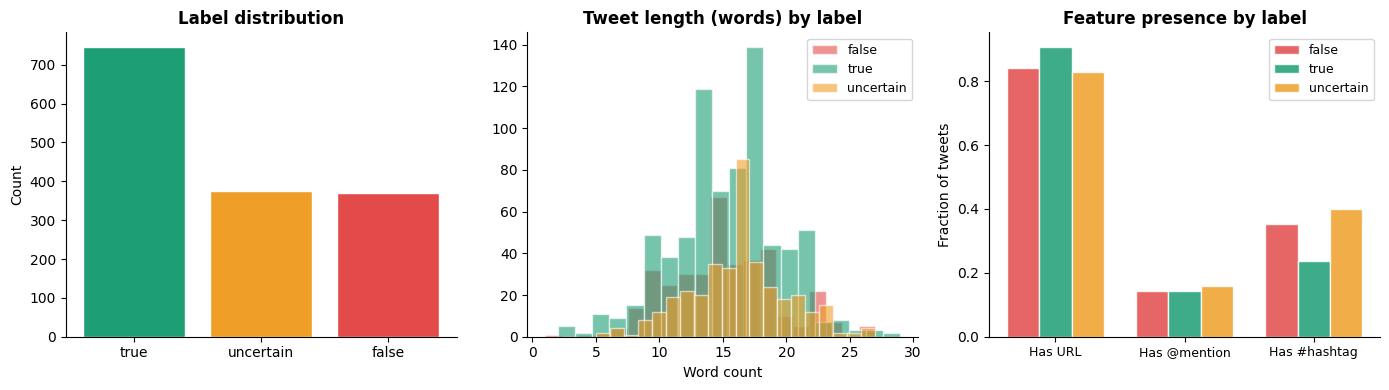

In [7]:
COLOR_MAP = {'false': '#E24B4A', 'true': '#1D9E75', 'uncertain': '#EF9F27'}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Label counts
counts = df['binary_label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLOR_MAP.get(l, '#888') for l in counts.index], edgecolor='white')
axes[0].set_title('Label distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# Tweet length by label
for lbl, grp in df.groupby('binary_label'):
    axes[1].hist(grp['word_len'].dropna(), bins=20, alpha=0.6,
                 color=COLOR_MAP.get(lbl, '#888'), label=lbl, edgecolor='white')
axes[1].set_title('Tweet length (words) by label', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

# Feature presence by label
features = ['has_url', 'has_mention', 'has_hashtag']
feat_data = df.groupby('binary_label')[features].mean()
width = 0.25
x = range(len(features))
for i, (lbl, row) in enumerate(feat_data.iterrows()):
    axes[2].bar([xi + i * width for xi in x], row.values, width=width,
                label=lbl, color=COLOR_MAP.get(lbl, '#888'), alpha=0.85, edgecolor='white')
axes[2].set_xticks([xi + width for xi in x])
axes[2].set_xticklabels(['Has URL', 'Has @mention', 'Has #hashtag'], fontsize=9)
axes[2].set_title('Feature presence by label', fontweight='bold')
axes[2].set_ylabel('Fraction of tweets')
axes[2].legend(fontsize=9)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('evaluation/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Save Merged Dataset for Later Phases

In [8]:
out_path = cfg.paths.data_processed / 'tweets_labeled.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
print(f'Saved to {out_path}')
print(df['binary_label'].value_counts().to_string())

Saved to /home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/tweets_labeled.csv
binary_label
true         746
uncertain    374
false        370
